# The irreducible mass of black holes
    
For a BH of mass $M$ spin $\chi\in [0,1]$, the irreducible mass is 
\begin{equation}
    M_{\rm irr} = %\sqrt{\frac{M^2+\sqrt{M^4-S^2}}{2}} = 
     M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
\end{equation}
For convenience, let us define 
\begin{equation}
    f(\chi) = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
\end{equation}

Suppose you have repeated measurments of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.
 
Let's assume that 
- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.
 
These are simplistic assumption that, however, are not too far from what we are now measuring with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks**:
   
1. Start with a value of $\sigma=0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu=1$ in your code and remember that all masses in the problem are measured in units of $\mu$. 
2. Plot the resulting pdf of $M_{\rm irr}$. First try an histogram with one the rules of thumb we've seen above.

*Hint (for point 2)*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.
4. Compute the KS distance between ${M_{\rm irr}}$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.
5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

*Hint (for points 4 and 5)*. This is a KS test between two sets for samples, `scipy.stats.ks_2samp`.

You should find that (i) $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

6. [**Optional, not examinable**] Compute the pdf of $f$ from its mathematical definition (pen and paper!). Verify this result:
\begin{equation}
    \pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}}
\end{equation}

7. [**Optional, not examinable**]  Compute the pdfs of $M_{\rm irr}$ from its mathematical definitions (pen and paper!). Verify this result:
\begin{equation}
    p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}df
\end{equation}
 The this expression is only semi-analytic; that integral should then be solved numerically.
 
*Hint (for point 7)*: You want to use [this theorem](https://en.wikipedia.org/wiki/Distribution_of_the_product_of_two_random_variables) for the product of two random variables.

8. Using the expressions from point 7 and 8, plot those pdfs check that they agree with your KDE reconstructions



In [13]:
import numpy as np
from matplotlib import pyplot as plt

from scipy.stats import norm
from scipy.stats import uniform
from scipy.stats import ks_2samp

from scipy.integrate import trapezoid
import astropy.visualization.hist
from sklearn.neighbors import KernelDensity


In [14]:
def irr_mass(M, chi):

    return M * np.sqrt( ( 1 + np.sqrt( 1 - chi ** 2) ) / 2)

def fun(chi):

    return np.sqrt( ( 1 + np.sqrt( 1 - chi ** 2) ) / 2)


### Rules of Thumb Distribution:

In [15]:
sigma = 0.02
mu = 1
N = 10000

chi = uniform.rvs(0, 1, N)
M = norm.rvs(mu, sigma, N)

Mirr = irr_mass(M, chi)
f = fun(chi)

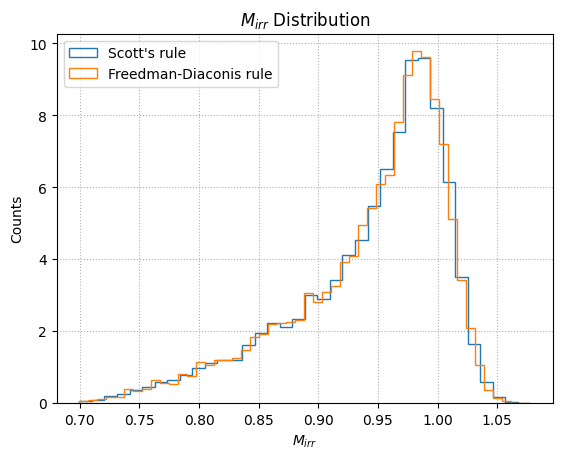

In [16]:
astropy.visualization.hist(Mirr, bins="scott", histtype="step",density=True, label = "Scott's rule")
astropy.visualization.hist(Mirr, bins="freedman", histtype="step",density=True, label = "Freedman-Diaconis rule")

plt.title("$M_{irr}$ Distribution")
plt.xlabel("$M_{irr}$")
plt.ylabel("Counts")
plt.legend()
plt.grid(linestyle = ":")
plt.show()

### KDE Distribution

In [17]:
x_i = np.linspace(Mirr.min(),Mirr.max(),N)

def kde_sklearn(data, bandwidth, kernel):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x_i[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

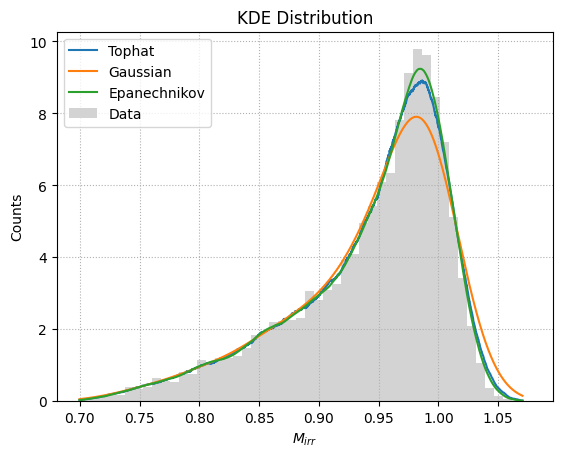

In [18]:
PDF_TH = kde_sklearn(Mirr, sigma, kernel="tophat") 
PDF_G = kde_sklearn(Mirr, sigma, kernel="gaussian") 
PDF_E = kde_sklearn(Mirr, sigma, kernel="epanechnikov") 

plt.plot(x_i, PDF_TH, label="Tophat")
plt.plot(x_i, PDF_G, label="Gaussian")
plt.plot(x_i, PDF_E, label="Epanechnikov")
astropy.visualization.hist(Mirr, bins="freedman", color ="lightgray", density=True, label = "Data")


plt.title("KDE Distribution")
plt.xlabel("$M_{irr}$")
plt.ylabel("Counts")
plt.legend()
plt.grid(linestyle = ":")
plt.show()

### KS Distance:

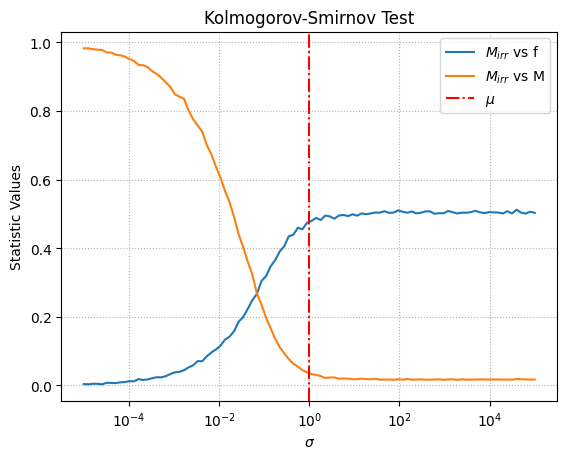

In [19]:
ks_f = []
ks_M = []
sigma_vec = np.logspace(-5, 5, 100)

for s in sigma_vec:
    M = norm.rvs(mu, s, N)
    chi = uniform.rvs(0, 1, N)

    ks_f_stat, _ = ks_2samp(fun(chi), irr_mass(M, chi))
    ks_M_stat, _ = ks_2samp(M, irr_mass(M, chi))

    ks_f.append(ks_f_stat)
    ks_M.append(ks_M_stat)

plt.plot(sigma_vec, ks_f, label="$M_{irr}$ vs f")
plt.plot(sigma_vec, ks_M, label="$M_{irr}$ vs M")
plt.axvline(mu, linestyle = '-.', c = 'r', label = "$\mu$")
plt.semilogx()

plt.title("Kolmogorov-Smirnov Test")
plt.xlabel("$\sigma$")
plt.ylabel("Statistic Values")
plt.legend()
plt.grid(linestyle = ":")
plt.show()

The graph shows two different behaviours: 

- On the right we have that the most probable model is for $M_{irr}$ to be distributed like $f$ ( ${\mu \gg \sigma}$);
- On the left we have that the most probable model is for $M_{irr}$ to be distributed like $M$ ( ${\sigma}\ll \mu$);

### Check with the Analitic Distribution

In [20]:
def integral(Mirr, f, mu, sigma):
    return np.exp( -( Mirr/f - mu )**2 / ( 2 * sigma**2 ) ) * ( ( 2 * f**2 - 1 ) / ( f * np.sqrt( 1 - f**2 ) ) )

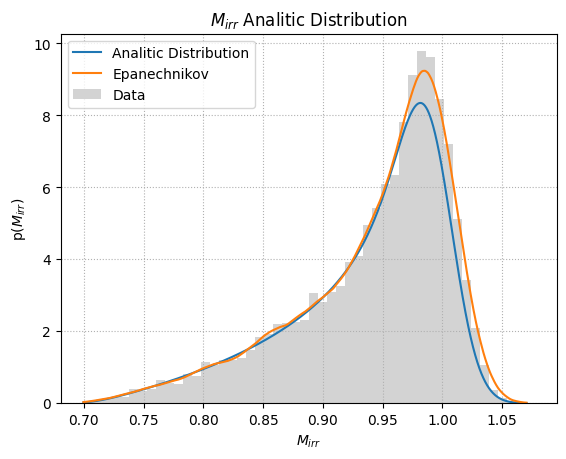

In [22]:
f_integral = np.linspace( 1/np.sqrt(2), 0.999, N)

pdf_Mirr = np.sqrt( 2 / np.pi ) / sigma * np.array([
    trapezoid(integral(x, f_integral, mu, sigma), dx = f_integral[1]-f_integral[0]) for x in x_i
])

plt.plot(x_i, pdf_Mirr, label = "Analitic Distribution")
plt.plot(x_i, PDF_E, label="Epanechnikov")
astropy.visualization.hist(Mirr, bins="freedman", color ="lightgray", density=True, label = "Data")

plt.title("$M_{irr}$ Analitic Distribution")
plt.xlabel("$M_{irr}$")
plt.ylabel("p($M_{irr}$)")
plt.legend()
plt.grid(linestyle = ":")
plt.show()